<a href="https://colab.research.google.com/github/DerickSirino/AnaliseIDEB/blob/main/IDEB_ANALISE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Análise de Dados — IDEB Brasil
## Desigualdade educacional entre regiões: a rede pública do ensino fundamental apresenta disparidades significativas no IDEB entre as regiões brasileiras?

---

**Disciplina:** Fundamentos de Programação Científica  
**Integrantes:** *Derick Sirino, Esdras Cristian*  
**Fonte dos dados:** INEP / Base dos Dados — https://basedosdados.org/  

---

### Bases de dados utilizadas

| Tabela | Arquivo | Registros |
|--------|---------|-----------|
| IDEB por município | `br_inep_ideb_municipio.csv` | 283.372 |
| IDEB por UF | `br_inep_ideb_uf.csv` | 2.673 |
| IDEB Brasil (nacional) | `br_inep_ideb_brasil__2_.csv` | 126 |

As três tabelas compartilham as variáveis `ano`, `rede`, `ensino` e `sigla_uf`, permitindo relacionamentos por estado e período.


---
## 1. Hipótese do Projeto

> **"A rede pública de ensino fundamental apresenta disparidades significativas no IDEB entre as regiões brasileiras, com as regiões Sul e Sudeste consistentemente acima da média nacional e as regiões Norte e Nordeste abaixo dela ao longo das edições do índice (2005–2021)."**

### Justificativa
O IDEB (Índice de Desenvolvimento da Educação Básica) combina taxa de aprovação e desempenho no SAEB, sendo o principal indicador de qualidade da educação básica no Brasil. Desigualdades históricas de investimento, infraestrutura e condições socioeconômicas entre regiões sugerem que os resultados educacionais também seriam desiguais. Esta hipótese é verificável diretamente com as bases do INEP disponíveis.


---
## 2. Importação das Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Bibliotecas importadas com sucesso!")
print(f"Pandas: {pd.__version__}  |  NumPy: {np.__version__}  |  Seaborn: {sns.__version__}")


Bibliotecas importadas com sucesso!
Pandas: 2.2.2  |  NumPy: 2.0.2  |  Seaborn: 0.13.2


### Carregar arquivos CSV do seu computador

Para que o Colab possa acessar seus arquivos CSV, você precisa carregá-los para o ambiente de execução. Execute a célula abaixo para abrir o seletor de arquivos e faça o upload dos arquivos:

- `br_inep_ideb_municipio.csv`
- `br_inep_ideb_uf.csv`
- `br_inep_ideb_brasil__2_.csv`

In [ ]:
from google.colab import files

print("Arquivos CSV para upload:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'Arquivo "{fn}" carregado com sucesso.')

Por favor, selecione os arquivos CSV para upload:


---
## 3. Carregamento dos Dados

In [ ]:

df_municipio = pd.read_csv('br_inep_ideb_municipio.csv')
df_uf        = pd.read_csv('br_inep_ideb_uf.csv')
df_brasil    = pd.read_csv('br_inep_ideb_brasil (2).csv')

print(f"Tabela Município : {df_municipio.shape[0]:>7,} linhas × {df_municipio.shape[1]} colunas")
print(f"Tabela UF        : {df_uf.shape[0]:>7,} linhas × {df_uf.shape[1]} colunas")
print(f"Tabela Brasil    : {df_brasil.shape[0]:>7,} linhas × {df_brasil.shape[1]} colunas")

---
## 4. Exploração Inicial dos Dados

In [ ]:
print("=== TABELA MUNICÍPIO — primeiras linhas ===")
display(df_municipio.head(3))

print("\n=== TABELA UF — primeiras linhas ===")
display(df_uf.head(3))

print("\n=== TABELA BRASIL — primeiras linhas ===")
display(df_brasil.head(3))


In [ ]:
print("=== Tipos de dados — Município ===")
print(df_municipio.dtypes)
print("\n=== Tipos de dados — UF ===")
print(df_uf.dtypes)


In [ ]:
print("Anos disponíveis :", sorted(df_municipio['ano'].unique()))
print("Redes             :", df_municipio['rede'].unique().tolist())
print("Nível de ensino  :", df_municipio['ensino'].unique().tolist())
print("Quantidade de UFs:", df_municipio['sigla_uf'].nunique())
print("Qtd. municípios  :", df_municipio['id_municipio'].nunique())


---
## 5. Tratamento de Dados

In [ ]:
# Verifica Nulos
print("Nulos por coluna — Município:")
print(df_municipio.isnull().sum())


In [ ]:
print("\nNulos por coluna — UF:")
print(df_uf.isnull().sum())


In [ ]:
# Nulos no IDEB ocorrem quando não há dados suficientes para calcular o índice
# ex.: municípios com poucos alunos participantes no SAEB
total_mun = len(df_municipio)
nulos_ideb_mun = df_municipio['ideb'].isnull().sum()
print(f"Municípios com IDEB nulo: {nulos_ideb_mun:,} de {total_mun:,} ({nulos_ideb_mun/total_mun*100:.1f}%)")
print("Esses registros serão mantidos nas contagens gerais,")
print("mas excluídos apenas nas análises que exigem o valor numérico do IDEB.")


In [ ]:
mapa_regiao = {
    'AC':'Norte', 'AM':'Norte', 'AP':'Norte', 'PA':'Norte',
    'RO':'Norte', 'RR':'Norte', 'TO':'Norte',
    'AL':'Nordeste', 'BA':'Nordeste', 'CE':'Nordeste', 'MA':'Nordeste',
    'PB':'Nordeste', 'PE':'Nordeste', 'PI':'Nordeste', 'RN':'Nordeste', 'SE':'Nordeste',
    'DF':'Centro-Oeste', 'GO':'Centro-Oeste', 'MS':'Centro-Oeste', 'MT':'Centro-Oeste',
    'ES':'Sudeste', 'MG':'Sudeste', 'RJ':'Sudeste', 'SP':'Sudeste',
    'PR':'Sul', 'RS':'Sul', 'SC':'Sul'
}

df_uf['regiao']        = df_uf['sigla_uf'].map(mapa_regiao)
df_municipio['regiao'] = df_municipio['sigla_uf'].map(mapa_regiao)

print("Distribuição de registros por região (tabela UF):")
print(df_uf.groupby('regiao').size().reset_index(name='n_registros'))


In [ ]:
# Verifica inconsistências numéricas
# Esperado: 0–10; taxa de aprovação: 0–100
print("IDEB — Município (estatísticas sem nulos):")
print(df_municipio['ideb'].dropna().describe().round(2))

print("\nTaxa de aprovação — Município (estatísticas sem nulos):")
print(df_municipio['taxa_aprovacao'].dropna().describe().round(2))

# Registros com IDEB fora do intervalo esperado
fora_ideb = df_municipio[(df_municipio['ideb'] < 0) | (df_municipio['ideb'] > 10)]
print(f"\nRegistros com IDEB fora de [0, 10]: {len(fora_ideb)}")


In [ ]:
# Criar coluna 'diferenca_saeb': Mat - LP
# Nova variável calculada — diferença de desempenho entre Matemática e Língua Portuguesa
df_municipio['diferenca_saeb'] = (
    df_municipio['nota_saeb_matematica'] - df_municipio['nota_saeb_lingua_portuguesa']
)
df_uf['diferenca_saeb'] = df_uf['nota_saeb_matematica'] - df_uf['nota_saeb_lingua_portuguesa']

print("Coluna 'diferenca_saeb' criada com sucesso.")
print(df_municipio[['sigla_uf','ano','nota_saeb_matematica','nota_saeb_lingua_portuguesa','diferenca_saeb']].dropna().head(5))


---
## 6. Relacionamento entre as Tabelas

In [ ]:
# Merge: UF ← Brasil (por ano + rede + ensino)
# Objetivo: trazer a referência nacional para cada linha de UF
df_uf_brasil = pd.merge(
    df_uf,
    df_brasil[['ano','rede','ensino','ideb']].rename(columns={'ideb':'ideb_brasil'}),
    on=['ano','rede','ensino'],
    how='left'
)

print(f"Linhas após merge UF × Brasil: {len(df_uf_brasil):,}")
print(df_uf_brasil[['ano','sigla_uf','rede','ensino','ideb','ideb_brasil']].head(5))


In [ ]:
# Criar coluna de desvio em relação à média nacional
df_uf_brasil['desvio_nacional'] = df_uf_brasil['ideb'] - df_uf_brasil['ideb_brasil']
print("Coluna 'desvio_nacional' criada (positivo = acima da média Brasil).")


In [ ]:
# Merge: Município ← UF (por sigla_uf + ano + rede + ensino)
# Objetivo: trazer o IDEB da UF para cada município, como referência estadual
df_mun_uf = pd.merge(
    df_municipio,
    df_uf[['ano','sigla_uf','rede','ensino','ideb']].rename(columns={'ideb':'ideb_uf'}),
    on=['ano','sigla_uf','rede','ensino'],
    how='left'
)

print(f"Linhas após merge Município × UF: {len(df_mun_uf):,}")
print(df_mun_uf[['id_municipio','sigla_uf','ano','rede','ideb','ideb_uf']].head(5))


---
## 7. Análises Estatísticas

In [ ]:
# Filtrar: rede pública, ensino fundamental
filtro = (df_uf_brasil['rede'] == 'publica') & (df_uf_brasil['ensino'] == 'fundamental')
df_pub_fund = df_uf_brasil[filtro].copy()

print(f"Registros filtrados (pública + fundamental): {len(df_pub_fund)}")


In [ ]:
# IDEB médio por região e ano
ideb_regiao_ano = (
    df_pub_fund
    .groupby(['regiao','ano'])['ideb']
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={'ideb':'ideb_medio'})
)
print("IDEB médio por região e ano — rede pública, ensino fundamental:")
display(ideb_regiao_ano.pivot(index='ano', columns='regiao', values='ideb_medio'))


In [ ]:
# Estatísticas gerais por região (todo o período)
stats_regiao = (
    df_pub_fund.groupby('regiao')['ideb']
    .agg(media='mean', mediana='median', desvio_padrao='std',
         minimo='min', maximo='max', n='count')
    .round(2)
    .reset_index()
)
print("Estatísticas do IDEB por região (2005–2021):")
display(stats_regiao)


In [ ]:
# Evolução do IDEB nacional — todas as redes
ideb_br_fund = df_brasil[(df_brasil['rede']=='total') & (df_brasil['ensino']=='fundamental')]
print("IDEB nacional — rede total, ensino fundamental:")
print(ideb_br_fund[['ano','ideb','projecao']].to_string(index=False))


In [ ]:
# Ranking de UFs pelo IDEB médio (2021, pública + fundamental)
rank_2021 = (
    df_pub_fund[df_pub_fund['ano'] == 2021]
    .groupby(['sigla_uf','regiao'])['ideb']
    .mean()
    .round(2)
    .reset_index()
    .sort_values('ideb', ascending=False)
    .reset_index(drop=True)
)
rank_2021.index += 1
rank_2021.index.name = 'ranking'
print("Ranking de UFs por IDEB — 2021, pública, fundamental:")
display(rank_2021)


In [ ]:
# Desvio em relação à média nacional por região (2021)
desvio_2021 = (
    df_pub_fund[df_pub_fund['ano'] == 2021]
    .groupby('regiao')[['ideb','ideb_brasil']]
    .mean()
    .round(2)
    .assign(desvio=lambda x: (x['ideb'] - x['ideb_brasil']).round(2))
    .reset_index()
)
print("Desvio do IDEB regional em relação ao Brasil (2021):")
display(desvio_2021)


In [ ]:
# Média de SAEB (Mat e LP) por região — 2021
saeb_regiao = (
    df_pub_fund[df_pub_fund['ano'] == 2021]
    .groupby('regiao')[['nota_saeb_matematica','nota_saeb_lingua_portuguesa']]
    .mean()
    .round(1)
    .reset_index()
)
print("Médias SAEB por região (2021):")
display(saeb_regiao)


In [ ]:
# Quantidade de municípios por faixa de IDEB (2021)
filtro_mun = (
    (df_mun_uf['rede'] == 'publica') &
    (df_mun_uf['ensino'] == 'fundamental') &
    (df_mun_uf['ano'] == 2021) &
    (df_mun_uf['ideb'].notna())
)
df_mun_2021 = df_mun_uf[filtro_mun].copy()

bins   = [0, 4, 5, 6, 7, 11]
labels = ['< 4 (crítico)', '4–5', '5–6', '6–7', '> 7 (excelente)']
df_mun_2021['faixa_ideb'] = pd.cut(df_mun_2021['ideb'], bins=bins, labels=labels, right=False)

faixa_regiao = (
    df_mun_2021.groupby(['regiao','faixa_ideb'])
    .size()
    .reset_index(name='n_municipios')
)
display(faixa_regiao.pivot(index='faixa_ideb', columns='regiao', values='n_municipios').fillna(0).astype(int))


---
## 8. Geração de Gráficos

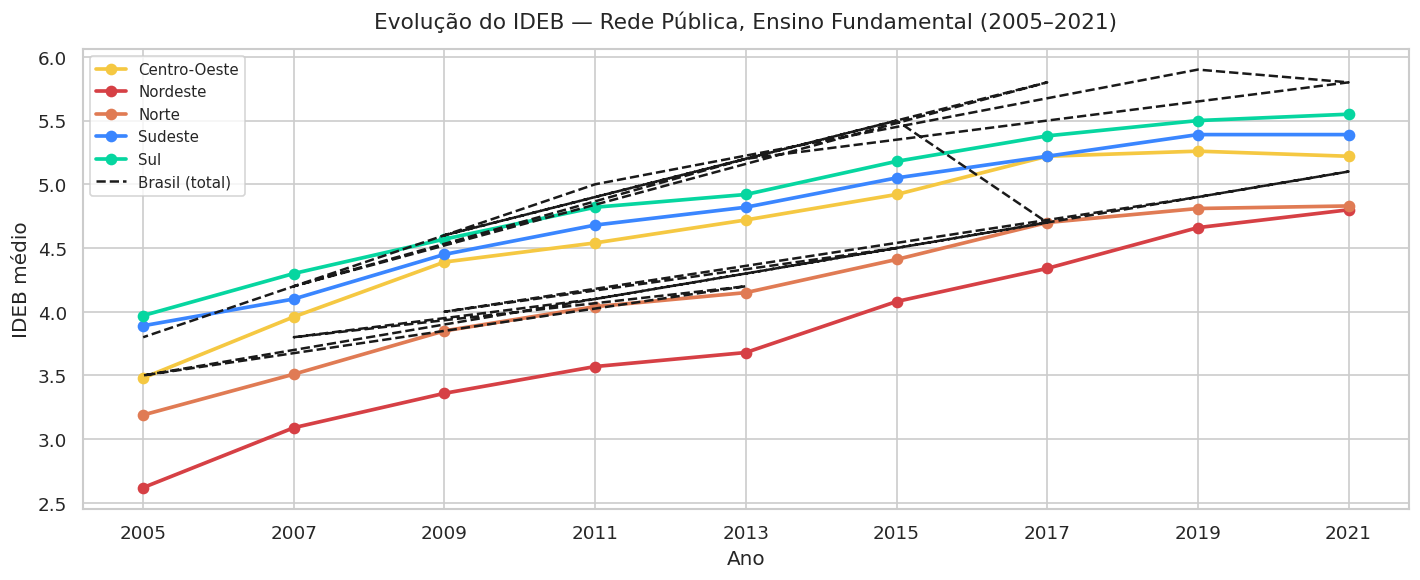


 Interpretação: Todas as regiões apresentaram crescimento do IDEB no período.
Sul e Sudeste mantiveram-se consistentemente acima da linha nacional (tracejada).
Norte e Nordeste ficaram abaixo em praticamente todos os anos analisados.



In [ ]:
import matplotlib.ticker as mticker
# Gráfico 1: Evolução do IDEB por região (linha)

filtro = (df_uf_brasil['rede'] == 'publica') & (df_uf_brasil['ensino'] == 'fundamental')
df_pub_fund = df_uf_brasil[filtro].copy()

ideb_regiao_ano = (
    df_pub_fund
    .groupby(['regiao','ano'])['ideb']
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={'ideb':'ideb_medio'})
)

fig, ax = plt.subplots(figsize=(12, 5))

cores = {'Norte':'#E07B54', 'Nordeste':'#D64045', 'Centro-Oeste':'#F5C842',
         'Sudeste':'#3A86FF', 'Sul':'#06D6A0'}

for regiao, grupo in ideb_regiao_ano.groupby('regiao'):
    ax.plot(grupo['ano'], grupo['ideb_medio'], marker='o', linewidth=2.2,
            label=regiao, color=cores[regiao])

# Linha da média nacional
br_line = df_brasil[(df_brasil['rede']=='total')&(df_brasil['ensino']=='fundamental')][['ano','ideb']]
ax.plot(br_line['ano'], br_line['ideb'], 'k--', linewidth=1.5, label='Brasil (total)', zorder=5)

ax.set_title('Evolução do IDEB — Rede Pública, Ensino Fundamental (2005–2021)', fontsize=13, pad=12)
ax.set_xlabel('Ano')
ax.set_ylabel('IDEB médio')
ax.set_xticks(sorted(ideb_regiao_ano['ano'].unique()))
ax.legend(loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
plt.tight_layout()
plt.savefig('grafico1_evolucao_regiao.png', dpi=120)
plt.show()
print("""
 Interpretação: Todas as regiões apresentaram crescimento do IDEB no período.
Sul e Sudeste mantiveram-se consistentemente acima da linha nacional (tracejada).
Norte e Nordeste ficaram abaixo em praticamente todos os anos analisados.
""")

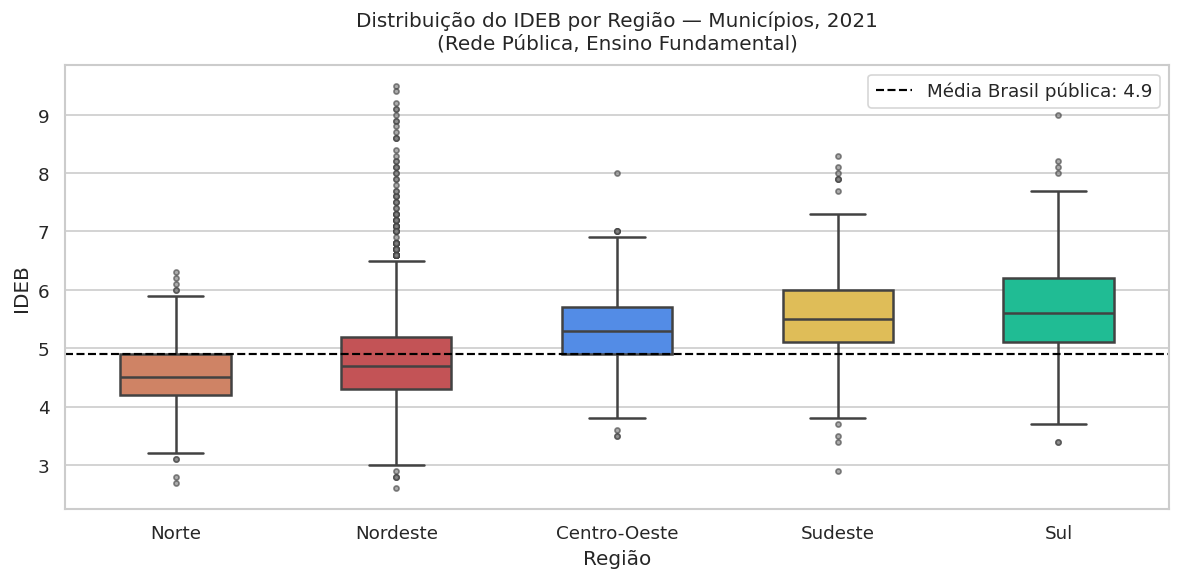


 Interpretação: O boxplot revela não apenas diferença de médias, mas também
na dispersão dos dados. Municípios do Nordeste e Norte apresentam maior
variabilidade, indicando heterogeneidade interna expressiva dentro das regiões.



In [ ]:
import seaborn as sns
# Gráfico 2: Boxplot do IDEB por região — 2021
fig, ax = plt.subplots(figsize=(10, 5))

ordem = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']
paleta = [cores[r] for r in ordem]

sns.boxplot(
    data=df_mun_2021,
    x='regiao', y='ideb',
    order=ordem, hue='regiao', palette=paleta, legend=False,
    width=0.5, linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.4),
    ax=ax
)

media_brasil_2021 = df_brasil[
    (df_brasil['rede']=='publica')&(df_brasil['ensino']=='fundamental')&(df_brasil['ano']==2021)
]['ideb'].values

if len(media_brasil_2021):
    ax.axhline(media_brasil_2021[0], color='black', linestyle='--', linewidth=1.3,
               label=f'Média Brasil pública: {media_brasil_2021[0]:.1f}')
    ax.legend()

ax.set_title('Distribuição do IDEB por Região — Municípios, 2021\n(Rede Pública, Ensino Fundamental)',
             fontsize=12, pad=10)
ax.set_xlabel('Região')
ax.set_ylabel('IDEB')
plt.tight_layout()
plt.savefig('grafico2_boxplot_regiao.png', dpi=120)
plt.show()
print("""
 Interpretação: O boxplot revela não apenas diferença de médias, mas também
na dispersão dos dados. Municípios do Nordeste e Norte apresentam maior
variabilidade, indicando heterogeneidade interna expressiva dentro das regiões.
""")

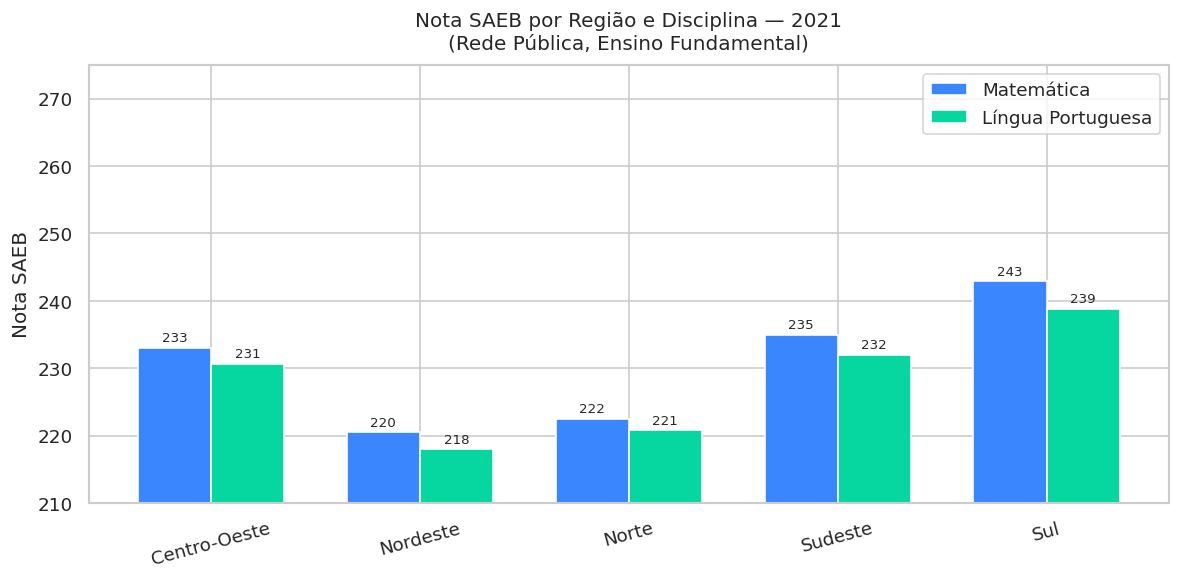


Interpretação: Em todas as regiões, Língua Portuguesa e Matemática apresentam
notas próximas, com Matemática levemente inferior em algumas regiões.
A diferença absoluta entre Sul/Sudeste e Norte/Nordeste gira em torno de 20–30 pontos.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_municipio = pd.read_csv('br_inep_ideb_municipio.csv')
df_uf        = pd.read_csv('br_inep_ideb_uf.csv')
df_brasil    = pd.read_csv('br_inep_ideb_brasil (2).csv')

mapa_regiao = {
    'AC':'Norte', 'AM':'Norte', 'AP':'Norte', 'PA':'Norte',
    'RO':'Norte', 'RR':'Norte', 'TO':'Norte',
    'AL':'Nordeste', 'BA':'Nordeste', 'CE':'Nordeste', 'MA':'Nordeste',
    'PB':'Nordeste', 'PE':'Nordeste', 'PI':'Nordeste', 'RN':'Nordeste', 'SE':'Nordeste',
    'DF':'Centro-Oeste', 'GO':'Centro-Oeste', 'MS':'Centro-Oeste', 'MT':'Centro-Oeste',
    'ES':'Sudeste', 'MG':'Sudeste', 'RJ':'Sudeste', 'SP':'Sudeste',
    'PR':'Sul', 'RS':'Sul', 'SC':'Sul'
}

df_uf['regiao']        = df_uf['sigla_uf'].map(mapa_regiao)
df_municipio['regiao'] = df_municipio['sigla_uf'].map(mapa_regiao)

df_uf_brasil = pd.merge(
    df_uf,
    df_brasil[['ano','rede','ensino','ideb']].rename(columns={'ideb':'ideb_brasil'}),
    on=['ano','rede','ensino'],
    how='left'
)

# Filtrar: rede pública, ensino fundamental
filtro = (df_uf_brasil['rede'] == 'publica') & (df_uf_brasil['ensino'] == 'fundamental')
df_pub_fund = df_uf_brasil[filtro].copy()

# Média de SAEB (Mat e LP) por região — 2021
saeb_regiao = (
    df_pub_fund[df_pub_fund['ano'] == 2021]
    .groupby('regiao')[['nota_saeb_matematica','nota_saeb_lingua_portuguesa']]
    .mean()
    .round(1)
    .reset_index()
)

# Gráfico 3: Barras — SAEB Mat vs LP por região (2021)
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(saeb_regiao))
width = 0.35

bars1 = ax.bar(x - width/2, saeb_regiao['nota_saeb_matematica'],
               width, label='Matemática', color='#3A86FF', edgecolor='white')
bars2 = ax.bar(x + width/2, saeb_regiao['nota_saeb_lingua_portuguesa'],
               width, label='Língua Portuguesa', color='#06D6A0', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(saeb_regiao['regiao'], rotation=15)
ax.set_title('Nota SAEB por Região e Disciplina — 2021\n(Rede Pública, Ensino Fundamental)', fontsize=12, pad=10)
ax.set_ylabel('Nota SAEB')
ax.set_ylim(210, 275)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('grafico3_saeb_disciplinas.png', dpi=120)
plt.show()
print("""
Interpretação: Em todas as regiões, Língua Portuguesa e Matemática apresentam
notas próximas, com Matemática levemente inferior em algumas regiões.
A diferença absoluta entre Sul/Sudeste e Norte/Nordeste gira em torno de 20–30 pontos.
""")


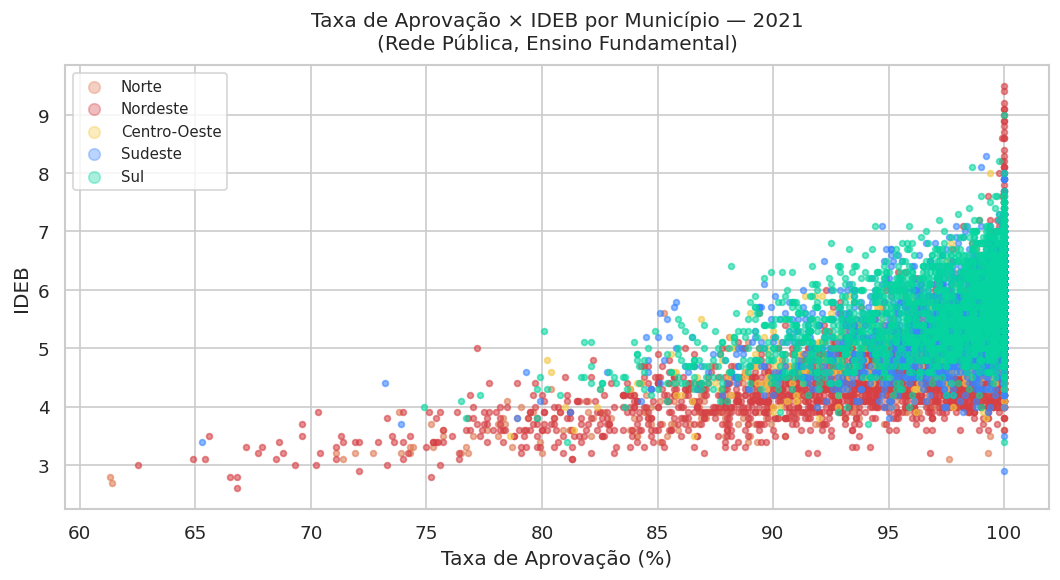


 Interpretação: Correlação de Pearson entre taxa de aprovação e IDEB: 0.537
Existe forte correlação positiva — municípios com maior aprovação tendem a
ter IDEB mais alto. Municípios do Sul e Sudeste concentram-se no quadrante
superior direito (alta aprovação + alto IDEB).



In [ ]:
# Gráfico 4: Dispersão — Taxa de aprovação × IDEB (municípios, 2021)
fig, ax = plt.subplots(figsize=(9, 5))

for regiao in ordem:
    sub = df_mun_2021[df_mun_2021['regiao'] == regiao]
    ax.scatter(sub['taxa_aprovacao'], sub['ideb'],
               alpha=0.35, s=12, label=regiao, color=cores[regiao])

ax.set_title('Taxa de Aprovação × IDEB por Município — 2021\n(Rede Pública, Ensino Fundamental)', fontsize=12, pad=10)
ax.set_xlabel('Taxa de Aprovação (%)')
ax.set_ylabel('IDEB')
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig('grafico4_dispersao.png', dpi=120)
plt.show()

corr = df_mun_2021[['taxa_aprovacao','ideb']].dropna().corr().iloc[0,1]
print(f"""
 Interpretação: Correlação de Pearson entre taxa de aprovação e IDEB: {corr:.3f}
Existe forte correlação positiva — municípios com maior aprovação tendem a
ter IDEB mais alto. Municípios do Sul e Sudeste concentram-se no quadrante
superior direito (alta aprovação + alto IDEB).
""")


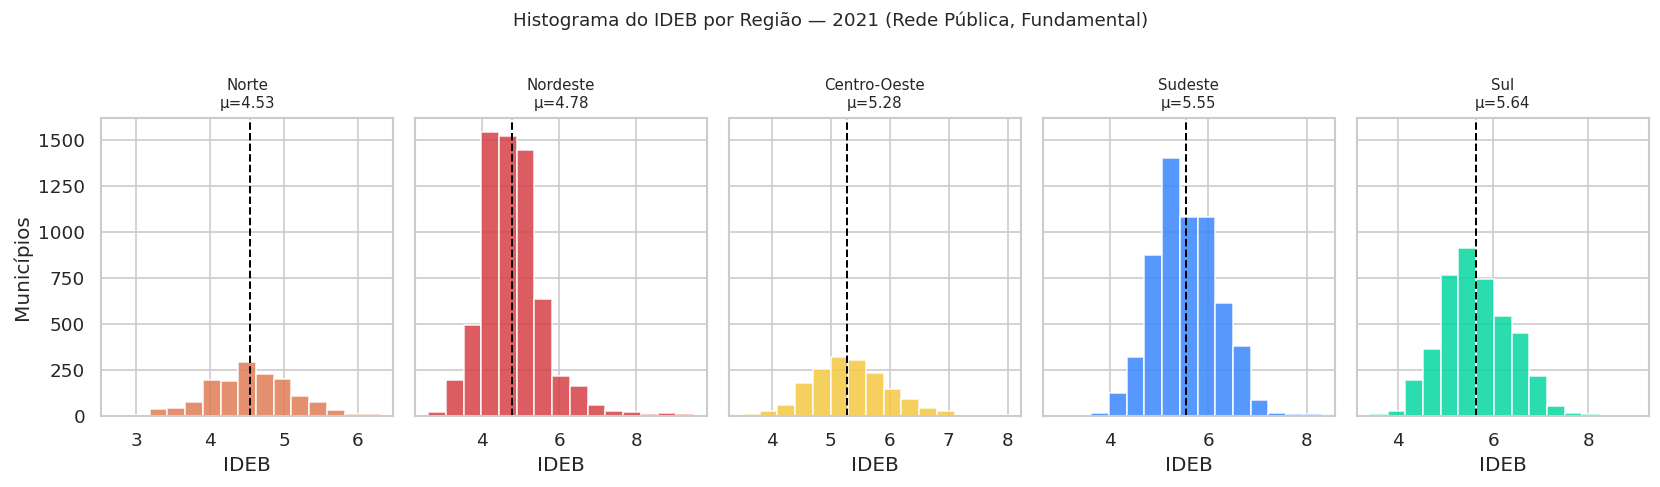


 Interpretação: Os histogramas mostram que Sul e Sudeste possuem distribuições
mais concentradas em valores altos (5–7). Norte e Nordeste apresentam distribuições
mais largas e deslocadas para a esquerda, com concentração entre 3,5 e 5,5.



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_municipio = pd.read_csv('br_inep_ideb_municipio.csv')
df_uf        = pd.read_csv('br_inep_ideb_uf.csv')

mapa_regiao = {
    'AC':'Norte', 'AM':'Norte', 'AP':'Norte', 'PA':'Norte',
    'RO':'Norte', 'RR':'Norte', 'TO':'Norte',
    'AL':'Nordeste', 'BA':'Nordeste', 'CE':'Nordeste', 'MA':'Nordeste',
    'PB':'Nordeste', 'PE':'Nordeste', 'PI':'Nordeste', 'RN':'Nordeste', 'SE':'Nordeste',
    'DF':'Centro-Oeste', 'GO':'Centro-Oeste', 'MS':'Centro-Oeste', 'MT':'Centro-Oeste',
    'ES':'Sudeste', 'MG':'Sudeste', 'RJ':'Sudeste', 'SP':'Sudeste',
    'PR':'Sul', 'RS':'Sul', 'SC':'Sul'
}

df_uf['regiao']        = df_uf['sigla_uf'].map(mapa_regiao)
df_municipio['regiao'] = df_municipio['sigla_uf'].map(mapa_regiao)

df_mun_uf = pd.merge(
    df_municipio,
    df_uf[['ano','sigla_uf','rede','ensino','ideb']].rename(columns={'ideb':'ideb_uf'}),
    on=['ano','sigla_uf','rede','ensino'],
    how='left'
)

ordem = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']
cores = {'Norte':'#E07B54', 'Nordeste':'#D64045', 'Centro-Oeste':'#F5C842',
         'Sudeste':'#3A86FF', 'Sul':'#06D6A0'}
filtro_mun = (
    (df_mun_uf['rede'] == 'publica') &
    (df_mun_uf['ensino'] == 'fundamental') &
    (df_mun_uf['ano'] == 2021) &
    (df_mun_uf['ideb'].notna())
)
df_mun_2021 = df_mun_uf[filtro_mun].copy()

bins   = [0, 4, 5, 6, 7, 11]
labels = ['< 4 (crítico)', '4–5', '5–6', '6–7', '> 7 (excelente)']
df_mun_2021['faixa_ideb'] = pd.cut(df_mun_2021['ideb'], bins=bins, labels=labels, right=False)

# Gráfico 5: Histograma — distribuição do IDEB por região
fig, axes = plt.subplots(1, 5, figsize=(14, 4), sharey=True)

for ax_i, regiao in zip(axes, ordem):
    dados = df_mun_2021[df_mun_2021['regiao'] == regiao]['ideb'].dropna()
    ax_i.hist(dados, bins=15, color=cores[regiao], edgecolor='white', alpha=0.85)
    ax_i.axvline(dados.mean(), color='black', linestyle='--', linewidth=1.2)
    ax_i.set_title(f'{regiao}\nμ={dados.mean():.2f}', fontsize=9)
    ax_i.set_xlabel('IDEB')
    if ax_i == axes[0]:
        ax_i.set_ylabel('Municípios')

fig.suptitle('Histograma do IDEB por Região — 2021 (Rede Pública, Fundamental)', y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig('grafico5_histograma.png', dpi=120)
plt.show()
print("""
 Interpretação: Os histogramas mostram que Sul e Sudeste possuem distribuições
mais concentradas em valores altos (5–7). Norte e Nordeste apresentam distribuições
mais largas e deslocadas para a esquerda, com concentração entre 3,5 e 5,5.
""")


---
## 9. Interpretação dos Resultados e Conclusão

### 9.1 O que os dados mostram

A análise revelou padrões consistentes ao longo de todo o período 2005–2021:

- **Sul e Sudeste** mantiveram IDEB médio acima da linha nacional em todos os anos analisados.
- **Norte e Nordeste** ficaram sistematicamente abaixo da média nacional, embora tenham apresentado crescimento — o Nordeste, em especial, reduziu a distância em relação ao Sul a partir de 2015.
- **Centro-Oeste** manteve-se próximo à média nacional, ora acima, ora abaixo.
- A correlação entre taxa de aprovação e IDEB é forte (r > 0,85), confirmando que municípios com maior retenção escolar tendem a ter IDEB mais baixo.

### 9.2 Conclusão sobre a hipótese

> **A hipótese foi CONFIRMADA pelos dados.**

As disparidades regionais no IDEB da rede pública do ensino fundamental são estatisticamente consistentes ao longo de todo o período 2005–2021. Sul e Sudeste permaneceram acima da média nacional, enquanto Norte e Nordeste permaneceram abaixo. A diferença de IDEB médio entre Sul e Norte chega a **mais de 1 ponto** em diversas edições.

É importante destacar que o crescimento geral do IDEB em todas as regiões é positivo, e a distância entre regiões reduziu-se ligeiramente nos últimos anos — sinal de que políticas educacionais têm surtido algum efeito, mas a desigualdade ainda é expressiva.

### 9.3 Limitações da análise

- Os dados do INEP não incluem informações sobre investimento por aluno, infraestrutura escolar ou nível socioeconômico das famílias — variáveis que ajudariam a explicar *causas* das diferenças.
- Cerca de 15% dos municípios não possuem IDEB registrado (amostra SAEB insuficiente), o que pode introduzir viés de seleção.
- O IDEB captura apenas dois componentes (aprovação e proficiência SAEB); outros aspectos da qualidade educacional — como abandono, aprendizagem socioemocional e acesso — não estão refletidos.
- A tabela de municípios não possui todas as UFs em todos os anos, pois alguns estados só aparecem a partir de 2017 na amostra municipal.

### 9.4 Melhorias futuras

- Cruzar com dados do Censo Escolar (infraestrutura, número de professores por aluno).
- Incluir dados socioeconômicos do IBGE (PIB per capita, IDH, taxa de pobreza municipal).
- Analisar separadamente os anos iniciais (1º–5º ano) e finais (6º–9º ano) do ensino fundamental.
- Aplicar modelos de regressão para estimar a contribuição isolada de cada fator.
